In [1]:
import gpt as g
import qlat as q
import numpy as np
import matplotlib.pyplot as plt

SharedMemoryMpi:  World communicator of size 1
SharedMemoryMpi:  Node  communicator of size 1
SharedMemoryMpi: SharedMemoryAllocate 1073741824 MMAP anonymous implementation 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the terms of the 

In [4]:
pipi_avg_data = np.load("/home/jhildebrand28/ktopipi/analysis/pipi_avg_data.npy")
print(pipi_avg_data.shape)

(25, 25, 25)


In [5]:
pipi_raw_data = np.load("/home/jhildebrand28/ktopipi/analysis/raw_pi_pos_data.npy")
print(pipi_raw_data.shape)

(97, 3, 25, 25, 25, 96)


hello


## Improved Vacuum sutraction for $I=0$ pion scattering

In lattice QCD, we can calulate Euclidean correlation functions directly, allowing us to find overlap with physical scattering states in a finite volume. For pion scattering, we calculate two pion two point functions, $C_{ij}^{(I,I_z)}(t) =  \langle O_{\pi\pi,\mathbf{p}}(t)O^{\dagger}_{\pi\pi,\mathbf{p}}(0)\rangle $, where $O_{\pi\pi,\mathbf{p}}$ is a two pion operator in the isospin 0 channel, $$\begin{equation}
\tilde{O}^{(I,I_z)}_{\pi\pi}(t_1,t_2,\vec{P},\vec{p}/2) = \sum_{ab}c^{(I,I_z)}_{ab} \ \pi^a(t_1,(\vec{P} + \vec{p})/2) \times\pi^b(t_2,(\vec{P} - \vec{p})/2)
\end{equation}$$ and $P$ is the total momentum, which we take to be zero, and $p$ is the relative momenta of each individual pion, projected such that the individual pions have equaland opposite momentum within a two pion operator. The lowest lying state of this object is the vacuum, so the calculation of such a correlation function on the lattice is contaminated with the vacuum state, and it must be subtracted. This subtraction is usually done using a product of two pion vacuum expectation values (vevs), subtracting timeslice by timeslice, 
$$
C^{0,0}_{ij}(t) = \left\langle O^{0,0}_i(t)O^{0,0}_j(-\Delta)^{\dagger} \right\rangle - \frac{1}{L_t}\sum_{t_{\text{src}} = 0}^{L_t - 1}\left\langle O^{0,0}_{i}(t + t_{\text{src}}) \right\rangle \left\langle O^{0,0}_j(t_{\text{src}}- \Delta)^{\dagger} \right\rangle
$$

This certainly subtracts the vacuum contribution, and it works quite well for the ground state momentum projections. However with the noisy point source data, the fluctuations of the vacuum contribution are larger than the characteristic exponential decay we expect from the other three contributions, making this vacuum subtraction very noisy,  and unable to resolve the physical states post-subtraction. 

The vacuum term itself is a correlated product of individual bubbles, 
$$
\langle O_{i,\mathbf{p}}(t)O^{\dagger}_{j,\mathbf{p}}(0)\rangle_V = \left\langle \sum_{\mathbf{x}, \mathbf{y}} e^{i\frac{\mathbf{p}_i}{2}\cdot\mathbf{x}} e^{i\frac{\mathbf{p}_j}{2}\cdot\mathbf{y}} \text{Tr}[\gamma_5 S_l(x_1,x_2)\gamma_5 S_l(x_2,x_1)]_i\times\text{Tr}[\gamma_5 S_l(x_3,x_4)\gamma_5 S_l(x_4,x_3)]_j \right\rangle
$$

where $\mathbf{x}$ and $\mathbf{y}$ are three vectors of relative coordinates, $x_1 - x_2$. This means that we could calculate each bubble individually and construct the correlated product to reconstruct the vacuum term which is found in the full correlator. By the Wick expansion, this vacuum contribution is just added to the other three contributions to construct the full correlator. Instead of doing the subtraction onb the full correlator, if we do the subtraction on each bubble individually and then reconstruct the vacuum term from the subtracted bubbles, this will reduce the noise as we are subtracting the vacuum contribution directly with a quantity that is averaged over the ensemble and certain lattice symmetries. If this subtraction reduces statistical error on each bubble, the product itself will have a much stronger signal than the traditional subtraction. 

Similar to the full correlator subtraction we, calculate a single vacuum bubble, which can be written $B(\mathbf{x},t_{\text{src}}) = \text{Tr}[\gamma_5 S_l(x_1,x_2)\gamma_5 S_l(x_2,x_1)]$, where we have used the same two pion operator as above, but we only focus on the vacuum term in the wick expansion. We then use the same two pion operator in a full vacuum expectation value calculation, but only in terms of relative coordinates in position space, $S = \langle B(\mathbf{x}) \rangle$. Note there is no source timeslice information in the average, this is only necessary in the individual bubbles, as we need this degree of freedom to reconstruct the total vacuum term. This average term gains more statistics the more lattice symmetries we average over as well, an in line with the single pion data analyzed before, the best gain is achieved from averaging over sign flips in the relative coordinates, while one could go as far as averaging over hypercubic rotations, or permutations of relative coordinates. Note the average term is averaged over configurations as well. 

Thus the subtraction goes like 

$$
V(t) = \left \langle \sum_{\mathbf{x}, \mathbf{y},t_{src}}  [B(\mathbf{x}, t + t_{src}) - \langle B(\mathbf{x}) \rangle] \times [B(\mathbf{y},t_src) - \langle B(\mathbf{y})\rangle] \right \rangle
$$

where the sum over $x$ and $y$ serve as part of the momentum projection of the operators, and the sum over $t_{src}$ is necessary to correlate the two bubbles to reconstruct the total vacuum term. 

### Functions

In [7]:
def jackblocks_all(data,omit,prt=0):
    #loop over timeslices
    #assuming shape (Ncf,...)
    jacks = np.zeros(data.shape,dtype=np.complex128)
    nconf=data.shape[0]
    other_dims=data.shape[1:]

    if(prt):print('omitting '+str(len(omit))+' of '+str(nconf)+' configs')

    #create mask for included configs
    include_mask = np.ones(nconf, dtype=bool)
    include_mask[omit] = False
    n_include = np.sum(include_mask)

    norm = 1.0 / (n_include - 1)

    total = np.sum(data[include_mask, ...], axis=0)

    jacks = np.zeros((n_include,) + other_dims, dtype=data.dtype)

    n = 0
    for i in range(nconf):
        if include_mask[i]:
            jacks[n,...] = (total - data[i,...]) * norm
            n += 1

    return jacks

#average and error calculation for a general shape vector of jackknife blocks
def jack_all(vec):
    n = vec.shape[0]
    avg = np.mean(vec,axis=0)

    err = np.zeros_like(avg)
    for i in range(n):
        err += (vec[i] - avg)*(vec[i] - avg)

    err *= (n-1)/n
    err = np.sqrt(err)
        
    return avg,err

In [60]:
def construct_V(bubble_raw_1,bubble_raw_2,tsep_max):
    ncf = bubble_raw_1.shape[0]
    nt = bubble_raw_1.shape[-1]
    Delta = 5
    vac = np.zeros((ncf, tsep_max),dtype=np.float64)

    for cf in range(ncf):
        for tsep in range(tsep_max):
            for t_src in range(nt):
                t1 = t_src
                t2 = (tsep + t_src + Delta) % nt

                vac[cf,tsep] += (bubble_raw_1[cf,t1] * bubble_raw_2[cf,t2])

    #print(vac.shape)
    return vac

#this is incorrect. The spatial coordinates are being treated element wise here, when there is zero correlation between them physically. 
def construct_V_pos(bubble_raw_1,bubble_raw_2,tsep_max):
    ncf = bubble_raw_1.shape[0]
    ns = bubble_raw_1.shape[1]
    nt = bubble_raw_1.shape[-1]
    Delta = 5
    vac = np.zeros((ncf, ns, ns, ns, tsep_max),dtype=np.float64)

    for cf in range(ncf):
        for tsep in range(tsep_max):
            for t_src in range(nt):
                t1 = t_src
                t2 = (tsep + t_src + Delta) % nt

                vac[cf,:,:,:,tsep] += (bubble_raw_1[cf,:,:,:,t1] * bubble_raw_2[cf,:,:,:,t2])

    #print(vac.shape)
    return vac

In [18]:
#sum over spatial separations, project to momentum space
def wave_function_mode_000(xrel,yrel,zrel,NS):
    w = np.ones_like(xrel)
    return w

#constructs the Fourier component for the (0,0,0) momentum config. 
#inputs are relative coordinates. 
def wave_function_mode_001(xrel,yrel,zrel,NS):
    w1 = np.cos(2.0 * np.pi * xrel / NS)
    w2 = np.cos(2.0 * np.pi * yrel / NS)
    w3 = np.cos(2.0 * np.pi * zrel / NS)
    w = (w1 + w2 + w3)/3.0
    return w

def wave_function_mode_011(xrel,yrel,zrel,NS):
    w1 = np.cos((2.0 * np.pi * xrel / NS) + (2.0 * np.pi * yrel / NS))
    w2 = np.cos((2.0 * np.pi * yrel / NS) + (2.0 * np.pi * zrel / NS))
    w3 = np.cos((2.0 * np.pi * xrel / NS) + (2.0 * np.pi * zrel / NS))
    w4 = np.cos((2.0 * np.pi * xrel / NS) - (2.0 * np.pi * yrel / NS))
    w5 = np.cos((2.0 * np.pi * yrel / NS) - (2.0 * np.pi * zrel / NS))
    w6 = np.cos((2.0 * np.pi * xrel / NS) - (2.0 * np.pi * zrel / NS))
    
    
    w = (w1 + w2 + w3 + w4 + w5 + w6)/6.0
    return w

def wave_function_mode_111(xrel,yrel,zrel,NS):
    w1 = np.cos((2.0 * np.pi * xrel / NS) + (2.0 * np.pi * yrel / NS) + (2.0 * np.pi * zrel / NS))
    w2 = np.cos(-(2.0 * np.pi * xrel / NS) + (2.0 * np.pi * yrel / NS) + (2.0 * np.pi * zrel / NS))
    w3 = np.cos((2.0 * np.pi * xrel / NS) - (2.0 * np.pi * yrel / NS) + (2.0 * np.pi * zrel / NS))
    w4 = np.cos((2.0 * np.pi * xrel / NS) + (2.0 * np.pi * yrel / NS) - (2.0 * np.pi * zrel / NS))
    
    w = (w1 + w2 + w3 + w4)/4.0
    return w

In [112]:
#function that applies the phase factor for every relative spatial coordinate configuration to be summed later. 
#we want to use this to apply the phase factor to the average data INSIDE the ensemble average
#input is the average bubble data, summed over the t_src index, with shape (ncf, ns, ns, ns)
def apply_phase(pos_corr, mode):
    ncf = pos_corr.shape[0]
    ns_mod = pos_corr.shape[-1]
    xrel,yrel,zrel = np.meshgrid(np.arange(ns_mod),np.arange(ns_mod),np.arange(ns_mod))

    # we calculate the array representing the phase at each point for any of the modes
    if mode == 0:
        ph = wave_function_mode_000(xrel,yrel,zrel,ns_mod*2-2)
    elif mode == 1:
        ph = wave_function_mode_001(xrel,yrel,zrel,ns_mod*2-2)
    elif mode == 2:
        ph = wave_function_mode_011(xrel,yrel,zrel,ns_mod*2-2)
    elif mode == 3:
        ph = wave_function_mode_111(xrel,yrel,zrel,ns_mod*2-2)

    ph_pi_avg = np.zeros_like(pos_corr)
    for cf in range(ncf):
        ph_pi_avg[cf] = (ph * pos_corr[cf])

    return ph_pi_avg


def mom_project_half(pos_corr, mode):
    Ncf,Nx,Ny,Nz,Nt = pos_corr.shape #extent in each direction
    x,y,z = np.meshgrid(np.arange(Nx),np.arange(Ny),np.arange(Nz))
    #x,y,z = np.meshgrid(np.arange(Nx),np.arange(Ny),np.arange(Nz))
    
    if mode == 0:
        ph = wave_function_mode_000(x,y,z,Nx*2-2)
    elif mode == 1:
        ph = wave_function_mode_001(x,y,z,Nx*2-2)
    elif mode == 2:
        ph = wave_function_mode_011(x,y,z,Nx*2-2)
    elif mode == 3:
        ph = wave_function_mode_111(x,y,z,Nx*2-2)

    #for each axis we say that each number has a multiplicity of 2

    if mode == 0:
        M = np.ones_like(x,dtype=int)
    else:
        M = np.ones_like(x,dtype=int)
        M = M * (2 - (x==0).astype(int) - (x==24).astype(int))
        M = M * (2 - (y==0).astype(int) - (y==24).astype(int))
        M = M * (2 - (z==0).astype(int) - (z==24).astype(int))
    
    #M = M * (2 - (t==0).astype(int))
    
    mom_corr = np.zeros((Ncf,Nt), np.float64)

    for cf in range(Ncf):
    #sum over spatial points for each timeslice
        for t in range(Nt):
            pos_arr = pos_corr[cf,:,:,:,t]
            #count_arr = counter[cf,:,:,:,t]

            #if mode == 0:
                #mom_corr[cf,t] = np.sum((ph * pos_arr),axis=(0,1,2))
            #else:
            mom_corr[cf,t] = np.sum((ph * pos_arr),axis=(0,1,2))

    return mom_corr

### Analysis

In [15]:
#construct average term. 

#we first must sum over this tsrc index which we have free
print(f"raw data array shape: {pipi_raw_data.shape}")
counters = np.sum(pipi_raw_data[:,0,:,:,:,:],axis=-1)
pi = np.sum(pipi_raw_data[:,1,:,:,:,:],axis=-1)

#we then use the counters array to average over equivalent relative coordinate configurations under the jackknife. 
counters_jk = jackblocks_all(counters,omit=[])
pi_jk = jackblocks_all(pi,omit=[])

pi_avg_jk = np.divide(pi_jk, counters_jk, where=(counters_jk>0))

#and since we are using the ensemble average in the subtraction, we do that here as well
pi_avg,pi_err = jack_all(pi_avg_jk.real)
print(f"average term shape: {pi_avg.shape}")

raw data array shape: (97, 3, 25, 25, 25, 96)
average term shape: (25, 25, 25)


In [115]:
#construct average term with phase factors applied

#we first must sum over this tsrc index which we have free
print(f"raw data array shape: {pipi_raw_data.shape}")
counters = np.sum(pipi_raw_data[:,0,:,:,:,:],axis=-1)
pi = np.sum(pipi_raw_data[:,1,:,:,:,:],axis=-1)

print(f"pre-phase pi shape: {pi.shape}")
#apply phase factors
ph_pi_000 = apply_phase(pi,0)
ph_pi_001 = apply_phase(pi,1)
ph_pi_011 = apply_phase(pi,2)
ph_pi_111 = apply_phase(pi,3)

#we then use the counters array to average over equivalent relative coordinate configurations under the jackknife. 
counters_jk = jackblocks_all(counters,omit=[])
pi_jk_000 = jackblocks_all(ph_pi_000,omit=[])
pi_jk_001 = jackblocks_all(ph_pi_001,omit=[])
pi_jk_011 = jackblocks_all(ph_pi_011,omit=[])
pi_jk_111 = jackblocks_all(ph_pi_111,omit=[])
print(f"jackknifed avg pi shape: {pi_jk_000.shape}")

#average using the counters array
pi_avg_jk_000 = np.divide(pi_jk_000, counters_jk, where=(counters_jk>0))
pi_avg_jk_001 = np.divide(pi_jk_001, counters_jk, where=(counters_jk>0))
pi_avg_jk_011 = np.divide(pi_jk_011, counters_jk, where=(counters_jk>0))
pi_avg_jk_111 = np.divide(pi_jk_111, counters_jk, where=(counters_jk>0))

#jack avg for each mode
pi_000_avg, pi_000_err = jack_all(pi_avg_jk_000)
pi_001_avg, pi_001_err = jack_all(pi_avg_jk_001)
pi_011_avg, pi_011_err = jack_all(pi_avg_jk_011)
pi_111_avg, pi_111_err = jack_all(pi_avg_jk_111)
print(f"average shape: {pi_000_avg.shape}")
np.save("pi_000_avg",pi_000_avg)
np.save("pi_001_avg",pi_001_avg)
np.save("pi_011_avg",pi_011_avg)
np.save("pi_111_avg",pi_111_avg)

raw data array shape: (97, 3, 25, 25, 25, 96)
pre-phase pi shape: (97, 25, 25, 25)
jackknifed avg pi shape: (97, 25, 25, 25)
average shape: (25, 25, 25)


In [99]:
#bubble term 
B_xt = pipi_raw_data[:,1,:,:,:,:]
C_xt = pipi_raw_data[:,0,:,:,:,:]
print(f"Bubble term array shape: {B_xt.shape}")

B_xt_jks = jackblocks_all(B_xt,omit=[])
C_xt_jks = jackblocks_all(C_xt,omit=[])

#for reconstructing the unsubtracted vacuum terms, we project this bubble data to all momenta
B_000 = mom_project_half(B_xt_jks.real,0)
B_001 = mom_project_half(B_xt_jks.real,1)
B_011 = mom_project_half(B_xt_jks.real,2)
B_111 = mom_project_half(B_xt_jks.real,3) 

Bubble term array shape: (97, 25, 25, 25, 96)


In [100]:
# show we can reconstruct the vacuum term
nOp = 4
tsep_max = 24
ncf = B_000.shape[0]
V_nosub = np.zeros((ncf, nOp, nOp, tsep_max))
B_list = [B_000, B_001, B_011, B_111]
for i in range(nOp):
    for j in range(nOp):
        V_nosub[:,i,j,:] = construct_V(B_list[i],B_list[j],tsep_max)

In [101]:
#V_nosub_jk = jackblocks_all(V_nosub,omit=[])
V_nosub_avg, V_nosub_err = jack_all(V_nosub_jk)
print(V_nosub_avg.shape)

(4, 4, 24)


<ErrorbarContainer object of 3 artists>

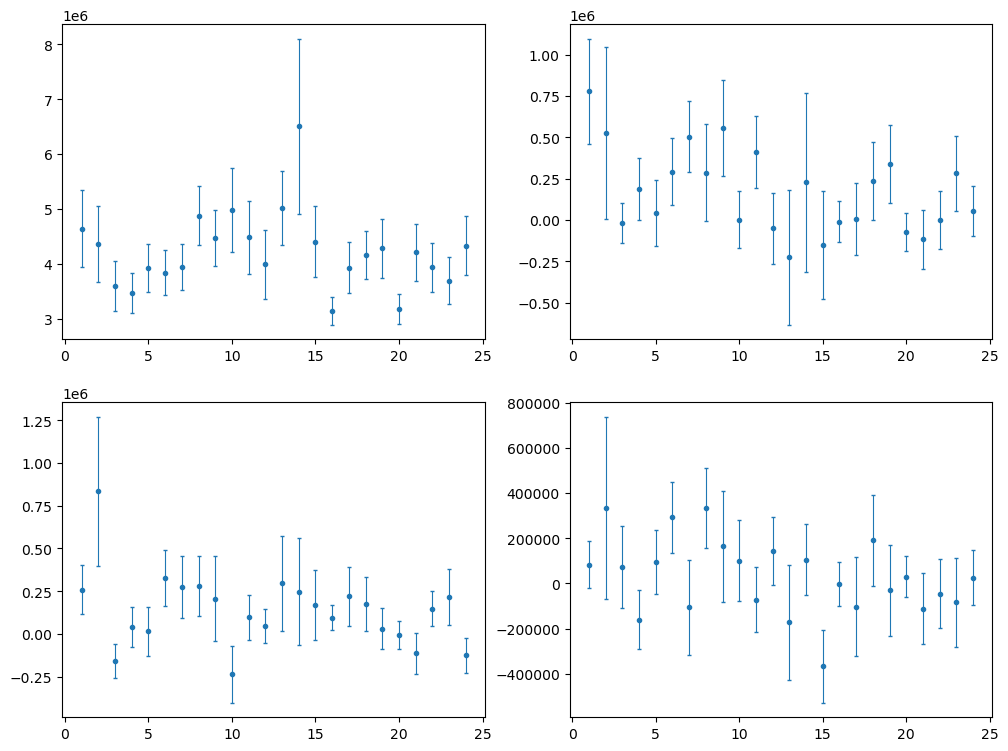

In [111]:
#plot the unsubtracted vacuum data.
ts = np.linspace(1,24,24)
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(12,9))

#ax[0,0].errorbar(ts, V_nosub_avg[0,0,1:], yerr=V_nosub_err[0,0,1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {0,0} vacuum term")
#ax[0,1].errorbar(ts, V_nosub_avg[1,1,1:], yerr=V_nosub_err[1,1,1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {1,1} vacuum term")
#ax[1,0].errorbar(ts, V_nosub_avg[2,2,1:], yerr=V_nosub_err[2,2,1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {2,2} vacuum term")
#ax[1,1].errorbar(ts, V_nosub_avg[3,3,1:], yerr=V_nosub_err[3,3,1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {3,3} vacuum term")

ax[0,0].errorbar(ts, V_000_avg[1:], yerr=V_000_err[1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {0,0} vacuum term")
ax[0,1].errorbar(ts, V_001_avg[1:], yerr=V_001_err[1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {1,1} vacuum term")
ax[1,0].errorbar(ts, V_011_avg[1:], yerr=V_011_err[1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {2,2} vacuum term")
ax[1,1].errorbar(ts, V_111_avg[1:], yerr=V_111_err[1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {3,3} vacuum term")





In [103]:
B_000_avg, B_000_err = jack_all(B_000.real)
B_001_avg, B_001_err = jack_all(B_001.real)
B_011_avg, B_011_err = jack_all(B_011.real)
B_111_avg, B_111_err = jack_all(B_111.real)

(-30000.0, 5000.0)

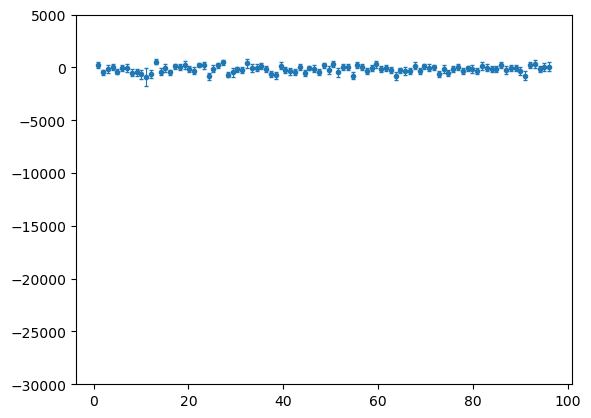

In [107]:
nt = np.linspace(1,96,95)
fig, ax = plt.subplots()
#ax.errorbar(nt, B_000_avg[1:], yerr=B_000_err[1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {0,0} vacuum term")
#ax.errorbar(nt, B_001_avg[1:], yerr=B_001_err[1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {1,1} vacuum term")
#ax.errorbar(nt, B_011_avg[1:], yerr=B_011_err[1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {2,2} vacuum term")
ax.errorbar(nt, B_111_avg[1:], yerr=B_111_err[1:], marker='.', ls='', elinewidth=0.8,capsize=1.5,label=f"mometnum {3,3} vacuum term")
ax.set_ylim(-30000,5000)

When dealing with the bubble object, the data we have is in the shape (ncf, nx_rel, ny_rel, nz_rel, t_src). Every set of source-sink pairs with the relative coordinate configuration and source timeslice are summed over to get this data. When we then sum over the remaining spatial axes, we have done the full sum reconstruction for the zero momentum projection, so no multiplicity factor needs to be appplied. This is why removing the multiplicity factor fixed the bubble reconstruction in the zero momentum case. This is only the case in the zero momentum case because the phase factor is 1 for all points, so we are effectively just summing over the whole volume, and we are free to segment this sum as much as we want.

For the nonzero momentum case, we would actually need a phase factor in the ac code if we wanted this to work the same way as the zero momentum case, which is entirely possible, but that is not how this data was generated. To get around this for this particular data, since the phase factor only depends on the relative distance between the source and sink, we can just count the number of times a particular relative coordinate configuration appears in the sum, and multiply by that number as a multiplicity factor.

This multiplicity issue is NOT an issue at all when using the autocontractor, since the full sum is being done there already. this mean that this is not our culprit for why the subtraction is not working on the nonzero momentum modes. 

The momentum projection function that I used in the single pion case for data of shape (nx_rel, ny_rel, nz_rel, nt_rel) worked, and allowed me to extract the single pion energies properly. Using this same momentum projection function here does not work, and I think the reason is that the data I am passing in has time index t_src, not t_rel. 